# Bank Marketing: Optimization of Telemarketing Campaigns via ML

## Project Objective
Build an end-to-end ML pipeline to predict term deposit conversions. The goal is to help the sales team prioritize high-probability leads, minimizing wasted call hours and reducing cost per acquisition (CPA).

## 1. Exploratory Data Analysis

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/bank-additional-full.csv', sep=';')

rename_dict = {
    'emp.var.rate': 'emp_var_rate',
    'cons.price.idx': 'cons_price_idx',
    'cons.conf.idx': 'cons_conf_idx',
    'euribor3m': 'euribor_3m',
    'nr.employed': 'nr_employed'
}

df = df.rename(columns=rename_dict)

# Dropping duration to prevent data leakage (unknown before the call)
df = df.drop(columns=['duration'])

# Encoding target to binary for correlation analysis
df['y'] = df['y'].map({'yes': 1, 'no': 0})

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  object 
 14  emp_var_rate    41188 non-null  float64
 15  cons_price_idx  41188 non-null  float64
 16  cons_conf_idx   41188 non-null  float64
 17  euribor_3m      41188 non-null 

### Macroeconomic Features & Multicollinearity

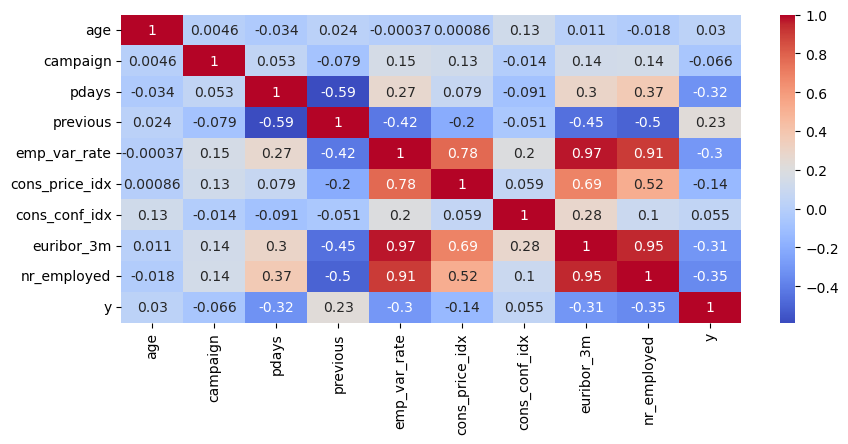

In [99]:
numerical = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numerical.corr()

plt.figure(figsize=(10, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

**Multicollinearity Analysis:** The macroeconomic features (`emp_var_rate`, `euribor_3m`, `nr_employed`) are highly collinear (correlation between 0.91 and 0.97). Keeping all of them will mess up feature importances and destabilize linear models.

**Decision:** Drop `emp_var_rate` and `nr_employed` during preprocessing, retaining only `euribor_3m` as a solid proxy for the economic context.

### Target Distribution & Class Imbalance

In [100]:
print('Absolute counts:')
print(df['y'].value_counts())
print('', '-'*40, '', sep='\n')

print('Percentage distribution:')
print(df['y'].value_counts(normalize=True) * 100)

Absolute counts:
y
0    36548
1     4640
Name: count, dtype: int64

----------------------------------------

Percentage distribution:
y
0    88.734583
1    11.265417
Name: proportion, dtype: float64


**Class Imbalance Interpretation:** The dataset is heavily skewed: only ~11% of clients actually converted. Because of this, standard accuracy is completely useless (a dummy model that always predicts "no" gets 88.7% accuracy but generates zero value).

**Decision:** We need to prioritize Recall (to capture as many real buyers as possible) and monitor F1-Score. Instead of using the default 0.5 probability threshold, I will tune the classification cutoff later to balance call center workload and conversion volume.

## 2. Feature Engineering & Preprocessing

### Train / Test Split
Splitting the data into train and test sets first to avoid any data leakage during preprocessing. Using stratification because the target variable is highly imbalanced (89/11 split).

In [101]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['y'])
y = df['y']

# Stratify is required due to class imbalance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")

X_train shape: (32950, 19) | X_test shape: (8238, 19)


### Feature Engineering & Dropping Collinear Features
**Macro Features:** Dropped `emp_var_rate` and `nr_employed` because they highly correlate with `euribor_3m`. Keeping only one to avoid multicollinearity.  
**pdays:** The value 999 means "never contacted". If we change it to 0, the model will think the client was called today, which breaks the logic. Instead, we create a binary flag `pdays_never_contacted` and map 999 to -1.

In [102]:
def process_features(dataframe):
    df_out = dataframe.copy()
    
    # Drop highly correlated macro metrics
    df_out = df_out.drop(columns=['emp_var_rate', 'nr_employed'])
    
    # Feature engineering for pdays
    df_out['pdays_never_contacted'] = (df_out['pdays'] == 999).astype(int)
    df_out['pdays'] = df_out['pdays'].replace(999, -1)
    
    return df_out

# Apply processing independently to avoid leakage
X_train_eng = process_features(X_train)
X_test_eng = process_features(X_test)

### Preprocessing Pipelines
Avoiding `pd.get_dummies` on the full dataset to prevent shape mismatches if the test set lacks certain categories. Using `ColumnTransformer` and `OneHotEncoder` instead.

Creating two different setups:  
1. **Linear Pipeline:** Encoding + scaling (`StandardScaler`) for Logistic Regression.  
2. **Tree Pipeline:** Only encoding for XGBoost/Random Forest.

In [103]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = X_train_eng.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train_eng.select_dtypes(include=['object', 'category']).columns.tolist()

# Linear models require scaling; tree-based models handle raw numerical scales
preprocessor_linear = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

## 3. Model Training & Evaluatio

### Logistic Regression Baseline
Training a baseline Logistic Regression model. We use `preprocessor_linear` to handle scaling and encoding, and set `class_weight='balanced'` to manage the 89/11 target split.

In [104]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

logreg_pipeline = Pipeline([
    ('prep', preprocessor_linear),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# Fit and evaluate
logreg_pipeline.fit(X_train_eng, y_train)
y_pred_lr = logreg_pipeline.predict(X_test_eng)

print("Logistic Regression Baseline:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Baseline:
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7310
           1       0.35      0.65      0.46       928

    accuracy                           0.83      8238
   macro avg       0.65      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238



### Tree-Based Approach (XGBoost)
Switching to XGBoost using `preprocessor_tree` (preserving unscaled numerical limits). We train the model on the native class distribution without internal weight scaling to ensure it outputs true, unskewed probabilities for our upcoming threshold optimization.

In [105]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ('prep', preprocessor_tree),
    ('clf', XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42, n_jobs=-1))
])

xgb_pipeline.fit(X_train_eng, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test_eng)

print("XGBoost (Default 0.5 Threshold):")
print(classification_report(y_test, y_pred_xgb))

XGBoost (Default 0.5 Threshold):
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7310
           1       0.69      0.25      0.37       928

    accuracy                           0.90      8238
   macro avg       0.80      0.62      0.66      8238
weighted avg       0.89      0.90      0.88      8238



### Out-of-Fold Threshold Optimization
To prevent data leakage, we find the optimal threshold using cross-validation on the training set only. The test set remains completely unseen until the final evaluation.

In [106]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve, classification_report

# Use out-of-fold probabilities on train set to prevent data leakage during threshold tuning
y_train_pred_probs = cross_val_predict(xgb_pipeline, X_train_eng, y_train, cv=5, method='predict_proba')[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, y_train_pred_probs)

f1_scores = [
    2 * p * r / (p + r) if (p + r) > 0 else 0
    for p, r in zip(precisions, recalls)
]

best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal Threshold found on Train CV: {best_threshold:.4f}\n")

# Apply the tuned threshold to the unseen test set
xgb_test_probs = xgb_pipeline.predict_proba(X_test_eng)[:, 1]
y_test_pred_custom = (xgb_test_probs >= best_threshold).astype(int)

print("Final XGBoost Performance on Test Set:")
print(classification_report(y_test, y_test_pred_custom))

Optimal Threshold found on Train CV: 0.1939

Final XGBoost Performance on Test Set:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      7310
           1       0.47      0.60      0.53       928

    accuracy                           0.88      8238
   macro avg       0.71      0.76      0.73      8238
weighted avg       0.89      0.88      0.89      8238



## 4. Feature Importance & Business Impact

### Feature Importance Analysis
We extract the feature importances directly from the trained XGBoost pipeline step and map them back to the encoded column names.

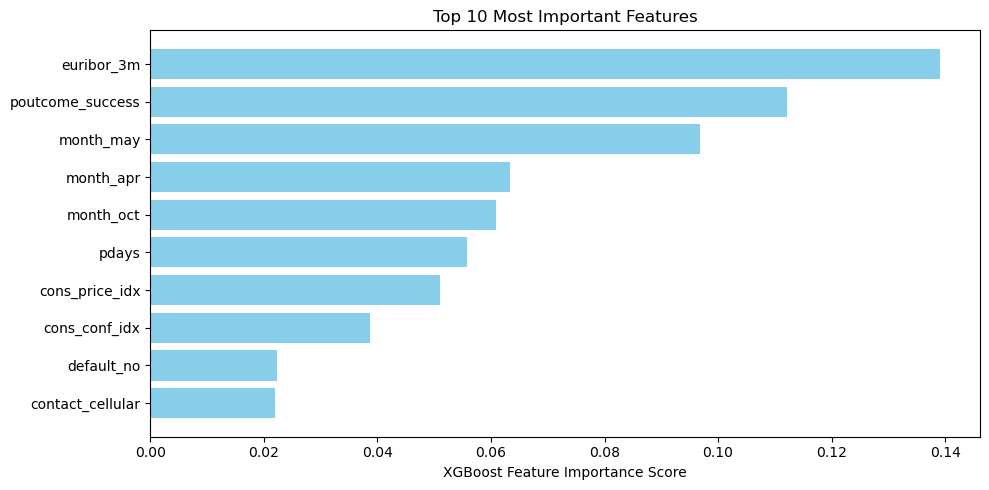

In [107]:
feature_names = xgb_pipeline.named_steps['prep'].get_feature_names_out()
importances = xgb_pipeline.named_steps['clf'].feature_importances_

feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
top_10_features = feature_imp_df.sort_values(by='Importance', ascending=False).head(10).copy()

# Strip prefixes added by ColumnTransformer for cleaner visualization
top_10_features['Feature'] = top_10_features['Feature'].str.replace('cat__', '').str.replace('remainder__', '')

plt.figure(figsize=(10, 5))
plt.barh(top_10_features['Feature'][::-1], top_10_features['Importance'][::-1], color='skyblue')
plt.xlabel('XGBoost Feature Importance Score')
plt.title('Top 10 Most Important Features')
plt.tight_layout()
plt.show()

### Key Insights & Estimated Business Value

**Macro over Behavior:** Economic indicators like `euribor_3m` dominate the splits. This proves that high-level market context heavily filters conversion likelihood before an agent even dials.  
**The Threshold Impact:** Moving the decision cutoff to the cross-validated optimum of `0.1939` boosted our Precision to **47%**. Compared to a baseline blind calling strategy (which converts at roughly 11.3%), the marketing team is now over **4x more efficient** with their call lists.  
**Operational Savings:** With this optimized threshold, the bank successfully captures **60%** of all available conversions while shielding the sales team from calling the vast majority of non-responsive leads. This drastically reduces the cost per acquisition (CPA).